In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import hist
import vector
import os
import subprocess
import gc
print("uproot version",uproot.__version__)
print("awkward version",ak.__version__)
print("numpy version",np.__version__)
print("matplotlib version",matplotlib.__version__)
print("hist version",hist.__version__)
print("vector version",vector.__version__)

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.1.3
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2


In [2]:
vector.register_awkward()

In [77]:
folder_path = "/pbs/throng/training/nantes-m2-rps-exp/data"
results = []
j_psi_gen = []
j_psi_rec = []

file_count =0

for file_name in os.listdir(folder_path):
    if file_name.endswith(".mc.root"):
        file_path = os.path.join(folder_path, file_name)
        results.append(file_name[0:-8])

        print(f"Traitement du fichier : {file_name}")
        file = uproot.open(file_path)

        gen = file["genTree"]
        n = gen.arrays([
            "nMuonsGen",
            "Muon_GenPx",
            "Muon_GenPy",
            "Muon_GenPz",
            "Muon_GenE",
            "Muon_GenLabel",
            "Muon_GenMotherPDGCode"
        ])

        nMuonsGen = 0
        for i in range(len(n)):
            info = n[i]["nMuonsGen"]
            nMuonsGen += info
        print("nMuonsGen = ", nMuonsGen)

        events = file["eventsTree"]
        m = events.arrays([
            "zVtx",
            "isCMUL",
            "nMuons",
            "Muon_Px",
            "Muon_Py",
            "Muon_Pz",
            "Muon_E",
            "Muon_Charge",
            "Muon_thetaAbs",
            "Muon_matchedTrgThreshold",
            "Muon_MCLabel"
        ])

        nMuons = 0
        for i in range(len(m)):
            info = m[i]["nMuons"]
            nMuons += info
        print("nMuons = ", nMuons)

        #-------------------------------------Pour 5 fichier seulement---------a supprimer plus tard (supprimer l'affichage surtout)--------------------
        file_count += 1
        #file_count >= 10
        if False :
            print("Limite de fichiers atteinte.")
            break
            
        mask = (m["nMuons"] >= 2) & ak.all(n["Muon_GenMotherPDGCode"] == 443, axis=1)
        filtered_gen_events = n[ak.all(n["Muon_GenMotherPDGCode"] == 443, axis=1)]
        filtered_events = m[mask & (m.isCMUL)&(abs(m.zVtx)<10)]
        print("nombre de Jpsi généré : ",len(filtered_gen_events))
        print("nombre de Jpsi reconstruit : ",len(filtered_events))
        j_psi_gen.append(len(filtered_gen_events))
        j_psi_rec.append(len(filtered_events))

#print(results)
#print(pT)


Traitement du fichier : run292140.mc.root
nMuonsGen =  14000
nMuons =  7742
nombre de Jpsi généré :  4681
nombre de Jpsi reconstruit :  943
Traitement du fichier : run290721.mc.root
nMuonsGen =  40000
nMuons =  21341
nombre de Jpsi généré :  13419
nombre de Jpsi reconstruit :  2546
Traitement du fichier : run292160.mc.root
nMuonsGen =  260000
nMuons =  143259
nombre de Jpsi généré :  86554
nombre de Jpsi reconstruit :  17549
Traitement du fichier : run291976.mc.root
nMuonsGen =  140000
nMuons =  77005
nombre de Jpsi généré :  46668
nombre de Jpsi reconstruit :  9322
Traitement du fichier : run291944.mc.root
nMuonsGen =  100000
nMuons =  55365
nombre de Jpsi généré :  33407
nombre de Jpsi reconstruit :  6860
Traitement du fichier : run291942.mc.root
nMuonsGen =  60000
nMuons =  33146
nombre de Jpsi généré :  19909
nombre de Jpsi reconstruit :  4129
Traitement du fichier : run292062.mc.root
nMuonsGen =  240000
nMuons =  131802
nombre de Jpsi généré :  80090
nombre de Jpsi reconstruit :  

In [131]:
        ################################### calcul du pT pour les Jpsi reconstruit ###################################
        muon_vectors = ak.zip({
            "px": filtered_events.Muon_Px,
            "py": filtered_events.Muon_Py,
            "pz": filtered_events.Muon_Pz,
            "E": filtered_events.Muon_E
        }, with_name="Momentum4D")

        jpsi_combi = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
        pT = (jpsi_combi.muon1 + jpsi_combi.muon2).pt

################################### calcul du pT pour les Jpsi généré ###################################
        muon_vectors_gen = ak.zip({
            "px": filtered_gen_events.Muon_GenPx,
            "py": filtered_gen_events.Muon_GenPy,
            "pz": filtered_gen_events.Muon_GenPz,
            "E": filtered_gen_events.Muon_GenE
        }, with_name="Momentum4D")

        jpsi_combi_gen = ak.combinations(muon_vectors_gen, 2, fields=["muonA", "muonB"])
        pT_gen = (jpsi_combi_gen.muonA + jpsi_combi_gen.muonB).pt

print("pT_rec : ", pT)
print("pT_gen : ", pT_gen)

pT_rec :  [[3.4], [4.66], [0.2], [5.78], [3.76], ..., [2.98], [0.372], [2.58], [6.28]]
pT_gen :  [[1.14], [2.93], [0.898], [2.33], [0.633], ..., [1.76], [5.21], [1.43], [1.61]]


In [132]:
#print(j_psi_gen)
#print(j_psi_rec)
print(len(pT))
#for i in pT :
 #   print(np.max(pT))
#print("tout les pT = ", pT)
#print(type(pT))
pT_min = []
pT_max = []
pT_f = ak.flatten(pT)  # Aplatir si c'est un awkward-array
for i in pT_f:
    if i <6:
        pT_min.append(i)
    else:
        pT_max.append(i)

N_rec, Bins_rec = np.histogram(pT_f,bins=20,range = (0,10)) #N_rec est le nombre de Jpsi reconstruit dans chaque intervalle en pT
print("pT = ", Bins_rec)

pT_gen_f = ak.flatten(pT_gen)  # Aplatir si c'est un awkward-array
pT_min_gen = []
pT_max_gen = []
for i in pT_gen_f:
    if i <6:
        pT_min_gen.append(i)
    else:
        pT_max_gen.append(i)
        
N_gen, Bins_gen = np.histogram(pT_gen_f,bins=20,range = (0,10)) #N_gen est le nombre de Jpsi généré dans chaque intervalle en pT
print("pT_gen = ", Bins_gen)
print("N_gen = ", N_gen)
print("N_rec = ", N_rec)

#print("len pT = ", len(Bins))
######################################### calcul de l'acceptance efficacité ##########################################
err_N_rec = [(N_rec[i])**(0.5) for i in range(len(N_rec))]
err_N_gen = [(N_gen[i])**(0.5) for i in range(len(N_gen))]
acceptance_eff = [float(N_rec[i]/N_gen[i]) for i in range(len(N_rec))]
err_acceptance_eff = [float(((err_N_rec[i]**2)/(N_rec[i]**2) + (err_N_gen[i]**2)/(N_gen[i]**2))**(0.5)) for i in range(len(N_rec))] #delta(AxE)/(AxE)

print("acceptance_eff = ",acceptance_eff, "+/- ",err_acceptance_eff)

19241
pT =  [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, ..., 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10]
pT_gen =  [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, ..., 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10]
N_gen =  [4.23e+03, 1.07e+04, 1.39e+04, 1.4e+04, 1.27e+04, ..., 617, 504, 343, 306, 179]
N_rec =  [752, 1.8e+03, 2.34e+03, 2.42e+03, 2.17e+03, ..., 180, 152, 135, 102, 65]
acceptance_eff =  [0.1776098252243741, 0.16846550915063352, 0.1690943178540525, 0.1725221365324193, 0.17065302911093627, 0.17590315869112919, 0.19157869481765835, 0.1979543666404406, 0.22263450834879406, 0.22113556098886172, 0.25947187141216993, 0.26108374384236455, 0.266934942991281, 0.27973977695167285, 0.3059125964010283, 0.2917341977309562, 0.30158730158730157, 0.3935860058309038, 0.3333333333333333, 0.36312849162011174] +/-  [0.039572345296513003, 0.02551383380451187, 0.02232818137511096, 0.022029876392362178, 0.023231878119402843, 0.025143706952164113, 0.027315484412276242, 0.030858855647807847, 0.033646232912643376, 0.03873198338377927, 

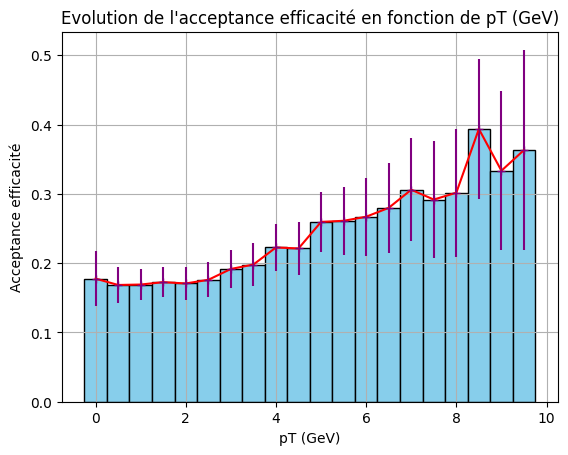

In [133]:
######################################### évolution de l'acceptance efficacité en fonction de pT ##########################################
plt.figure()       
plt.errorbar(Bins_rec[:-1],acceptance_eff, yerr=err_acceptance_eff, fmt='+',color = 'purple', label = 'erreur')
width = 10/len(Bins_rec[:-1])
plt.bar(Bins_rec[:-1], acceptance_eff,width = width, edgecolor='black', color='skyblue')
#plt.hist(Bins_rec[1:])
plt.plot(Bins_rec[:-1], acceptance_eff,'r')
plt.xlabel('pT (GeV)')
plt.ylabel("Acceptance efficacité")
plt.title("Evolution de l'acceptance efficacité en fonction de pT (GeV)")
plt.grid(True)
plt.show()

In [137]:
######################## séparation des gammes en énergie pour pT ############################################
N_rec_min, Bins_rec_min = np.histogram(pT_min,bins=12,range = (0,6)) #N_rec est le nombre de Jpsi reconstruit dans chaque intervalle en pT
print("pT = ", Bins_rec_min)

N_rec_max, Bins_rec_max = np.histogram(pT_max,bins=4,range = (6,10)) #N_rec est le nombre de Jpsi reconstruit dans chaque intervalle en pT
print("pT = ", Bins_rec_max)

N_gen_min, Bins_gen_min = np.histogram(pT_min_gen,bins=12,range = (0,6)) #N_gen est le nombre de Jpsi généré dans chaque intervalle en pT
print("pT = ", Bins_gen_min)

N_gen_max, Bins_gen_max = np.histogram(pT_max_gen,bins=4,range = (6,10)) #N_gen est le nombre de Jpsi généré dans chaque intervalle en pT
print("pT = ", Bins_gen_max)

######################################### calcul de l'acceptance efficacité ##########################################
err_N_rec_min = [(N_rec_min[i])**(0.5) for i in range(len(N_rec_min))]
err_N_rec_max = [(N_rec_max[i])**(0.5) for i in range(len(N_rec_max))]

err_N_gen_min = [(N_gen_min[i])**(0.5) for i in range(len(N_gen_min))]
err_N_gen_max = [(N_gen_max[i])**(0.5) for i in range(len(N_gen_max))]

acceptance_eff_min = [float(N_rec_min[i]/N_gen_min[i]) for i in range(len(N_rec_min))]
acceptance_eff_max = [float(N_rec_max[i]/N_gen_max[i]) for i in range(len(N_rec_max))]

err_acceptance_eff_min = [float(((err_N_rec_min[i]**2)/(N_rec_min[i]**2) + (err_N_gen_min[i]**2)/(N_gen_min[i]**2))**(0.5)) for i in range(len(N_rec_min))] #delta(AxE)/(AxE)
err_acceptance_eff_max = [float(((err_N_rec_max[i]**2)/(N_rec_max[i]**2) + (err_N_gen_max[i]**2)/(N_gen_max[i]**2))**(0.5)) for i in range(len(N_rec_max))] #delta(AxE)/(AxE)

#print("acceptance_eff = ",acceptance_eff, "+/- ",err_acceptance_eff)

pT =  [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]
pT =  [ 6.  7.  8.  9. 10.]
pT =  [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]
pT =  [ 6.  7.  8.  9. 10.]


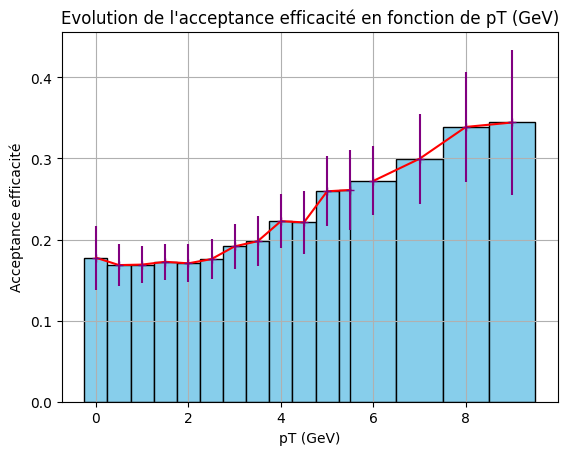

In [141]:
######################################### évolution de l'acceptance efficacité en fonction de pT ##########################################
plt.figure()       
plt.errorbar(Bins_rec_min[:-1],acceptance_eff_min, yerr=err_acceptance_eff_min, fmt='+',color = 'purple', label = 'erreur')
plt.errorbar(Bins_rec_max[:-1],acceptance_eff_max, yerr=err_acceptance_eff_max, fmt='+',color = 'purple', label = 'erreur')

width_min = 6/len(Bins_rec_min[:-1])
width_max = 4/len(Bins_rec_max[:-1])

plt.bar(Bins_rec_min[:-1], acceptance_eff_min,width = width_min, edgecolor='black', color='skyblue')
plt.bar(Bins_rec_max[:-1], acceptance_eff_max,width = width_max, edgecolor='black', color='skyblue')

#plt.hist(Bins_rec[1:])
plt.plot(Bins_rec_min[:-1], acceptance_eff_min,'r')
plt.plot(Bins_rec_max[:-1], acceptance_eff_max,'r')
plt.xlabel('pT (GeV)')
plt.ylabel("Acceptance efficacité")
plt.title("Evolution de l'acceptance efficacité en fonction de pT (GeV)")
plt.grid(True)
plt.show()